In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import rioxarray as rxr
from rioxarray.merge import merge_arrays
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as mticker
from rasterio.enums import Resampling
import geopandas as gpd
import regionmask
from shapely.geometry import box
import cartopy.io.img_tiles as cimgt

In [2]:
path='/projekt1/ag_maahn/data_obs_nobackup/amazonas/forest_loss/'

kacheln1 = [
    rxr.open_rasterio(path+"Hansen_GFC-2024-v1.12_lossyear_00N_050W.tif"),
    rxr.open_rasterio(path+"Hansen_GFC-2024-v1.12_lossyear_00N_060W.tif"),
    rxr.open_rasterio(path+"Hansen_GFC-2024-v1.12_lossyear_00N_070W.tif"),
    rxr.open_rasterio(path+"Hansen_GFC-2024-v1.12_lossyear_00N_080W.tif"),
    rxr.open_rasterio(path+"Hansen_GFC-2024-v1.12_lossyear_10N_050W.tif"),
    rxr.open_rasterio(path+"Hansen_GFC-2024-v1.12_lossyear_10N_060W.tif"),
    rxr.open_rasterio(path+"Hansen_GFC-2024-v1.12_lossyear_10N_070W.tif"),
    rxr.open_rasterio(path+"Hansen_GFC-2024-v1.12_lossyear_10N_080W.tif"),
    rxr.open_rasterio(path+"Hansen_GFC-2024-v1.12_lossyear_10S_050W.tif"),
    rxr.open_rasterio(path+"Hansen_GFC-2024-v1.12_lossyear_10S_060W.tif"),
    rxr.open_rasterio(path+"Hansen_GFC-2024-v1.12_lossyear_10S_070W.tif"),
    rxr.open_rasterio(path+"Hansen_GFC-2024-v1.12_lossyear_10S_080W.tif")
]
mrd1 = merge_arrays(kacheln1)

In [3]:
path2='/projekt1/ag_maahn/data_obs_nobackup/amazonas/cover2000/'

kacheln2 = [
    rxr.open_rasterio(path2+"Hansen_GFC-2024-v1.12_treecover2000_00N_050W.tif"),
    rxr.open_rasterio(path2+"Hansen_GFC-2024-v1.12_treecover2000_00N_060W.tif"),
    rxr.open_rasterio(path2+"Hansen_GFC-2024-v1.12_treecover2000_00N_070W.tif"),
    rxr.open_rasterio(path2+"Hansen_GFC-2024-v1.12_treecover2000_00N_080W.tif"),
    rxr.open_rasterio(path2+"Hansen_GFC-2024-v1.12_treecover2000_10N_050W.tif"),
    rxr.open_rasterio(path2+"Hansen_GFC-2024-v1.12_treecover2000_10N_060W.tif"),
    rxr.open_rasterio(path2+"Hansen_GFC-2024-v1.12_treecover2000_10N_070W.tif"),
    rxr.open_rasterio(path2+"Hansen_GFC-2024-v1.12_treecover2000_10N_080W.tif"),
    rxr.open_rasterio(path2+"Hansen_GFC-2024-v1.12_treecover2000_10S_050W.tif"),
    rxr.open_rasterio(path2+"Hansen_GFC-2024-v1.12_treecover2000_10S_060W.tif"),
    rxr.open_rasterio(path2+"Hansen_GFC-2024-v1.12_treecover2000_10S_070W.tif"),
    rxr.open_rasterio(path2+"Hansen_GFC-2024-v1.12_treecover2000_10S_080W.tif")
]

mrd2 =merge_arrays(kacheln2)

In [4]:
SG=22

In [5]:
cvr = mrd2.to_dataset(name="cover2000")
loss = mrd1.to_dataset(name='loss')
ds=xr.merge([loss, cvr])
cvr

/tmp/ipykernel_2937419/3859012461.py:3: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds=xr.merge([loss, cvr])


<xarray.Dataset> Size: 19GB
Dimensions:      (x: 160000, y: 120000, band: 1)
Coordinates:
  * x            (x) float64 1MB -80.0 -80.0 -80.0 -80.0 ... -40.0 -40.0 -40.0
  * y            (y) float64 960kB 10.0 10.0 9.999 9.999 ... -20.0 -20.0 -20.0
  * band         (band) int64 8B 1
    spatial_ref  int64 8B 0
Data variables:
    cover2000    (band, y, x) uint8 19GB 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0

In [6]:
amazon = gpd.read_file("/projekt1/ag_maahn/data_obs_nobackup/amazonas/shape/raisg/Lim_Raisg.shp")
amazon2 = gpd.read_file("/projekt1/ag_maahn/data_obs_nobackup/amazonas/shape/biogeo/Lim_Biogeografico.shp")

south_box = box(-85, -25, -30, 0)   # (minx, miny, maxx, maxy) — adjust to your area
amazon_south = gpd.clip(amazon2, south_box)

In [7]:
#choose resolution

res=0.1 #°

maxX = round(float(cvr['x'].max()),0)
minX = round(float(cvr['x'].min()),0)

maxY = round(float(cvr['y'].max()),0)
minY = round(float(cvr['y'].min()),0)

In [19]:
# set boundary values for map-plots
lon_min, lon_max = -79.5, -43
lat_min, lat_max = -18, 0

In [9]:
mp = cvr.groupby_bins('x', np.arange(minX, maxX+res, res)).mean() \
        .groupby_bins('y', np.arange(minY, maxY+res, res)).mean()
mp

<xarray.Dataset> Size: 971kB
Dimensions:      (y_bins: 300, x_bins: 400, band: 1)
Coordinates:
  * y_bins       (y_bins) interval[float64, right] 5kB (-20.0, -19.9] ... (9....
  * x_bins       (x_bins) interval[float64, right] 6kB (-80.0, -79.9] ... (-4...
  * band         (band) int64 8B 1
    spatial_ref  int64 8B 0
Data variables:
    cover2000    (y_bins, x_bins, band) float64 960kB 0.0 0.0 0.0 ... 0.0 0.0

In [10]:
mp=mp.sel(band=1)
mp

<xarray.Dataset> Size: 971kB
Dimensions:      (y_bins: 300, x_bins: 400)
Coordinates:
  * y_bins       (y_bins) interval[float64, right] 5kB (-20.0, -19.9] ... (9....
  * x_bins       (x_bins) interval[float64, right] 6kB (-80.0, -79.9] ... (-4...
    band         int64 8B 1
    spatial_ref  int64 8B 0
Data variables:
    cover2000    (y_bins, x_bins) float64 960kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0

In [11]:
my_cmap = mcolors.LinearSegmentedColormap.from_list(
    'my_cmap',
    ['peru', 'lightyellow', 'yellow','yellowgreen' ,'green','darkgreen'],  # colors
    N=256  # interpolation steps
)

/home/oscholz/miniforge3/envs/modis_env/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


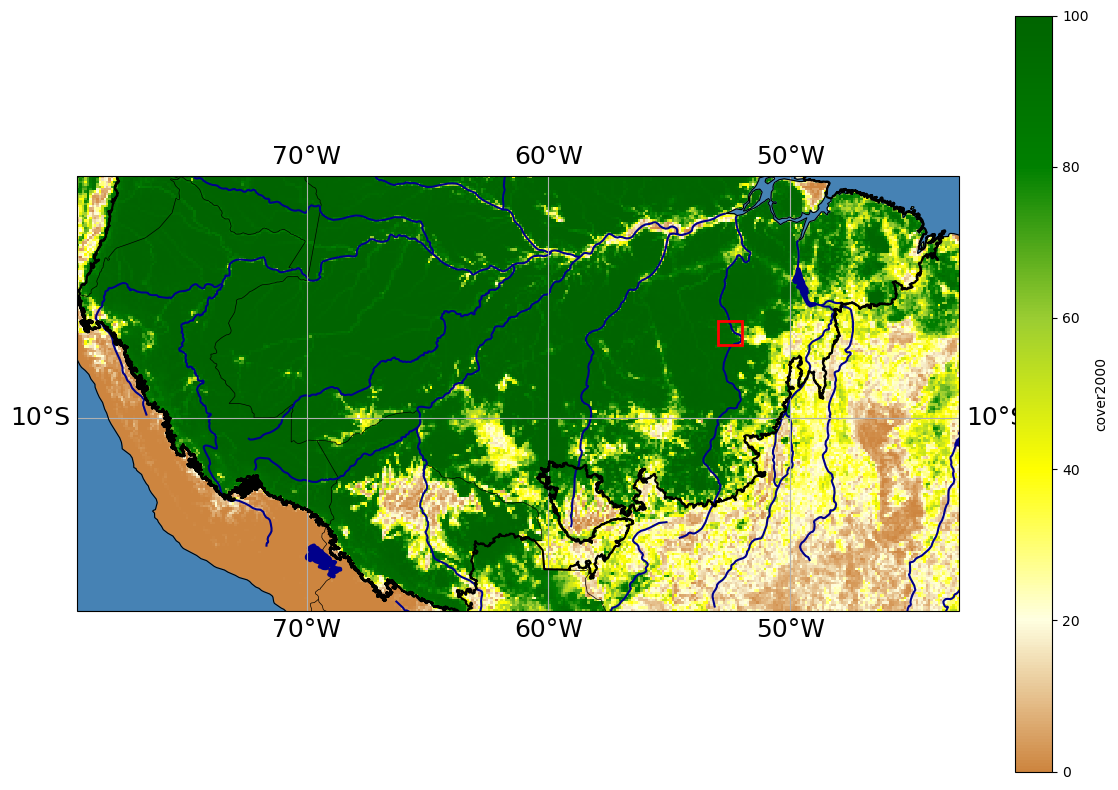

In [25]:
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})

dp=mp['cover2000'].plot.pcolormesh(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap=my_cmap,
    vmin=0, vmax=100,
    cbar_kwargs={'label': 'Forest cover in %', 'pad': 0.065, 'shrink': 0.55}
)
dp.colorbar.set_label('Forest cover in %', fontsize=SG)
dp.colorbar.ax.tick_params(labelsize=(SG-4))

ax.add_geometries(
    amazon_south.geometry,
    crs=ccrs.PlateCarree(),
    facecolor="none",
    edgecolor="black",
    linewidth=1.5,
    zorder=5   # make sure it's drawn on top
)

ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.OCEAN, zorder=2, color='steelblue')
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=3)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.RIVERS, linewidth=1.5, color='darkblue')
ax.add_feature(cfeature.LAKES, linewidth=2, color='darkblue')

gl = ax.gridlines(draw_labels=True)
gl.xlocator = mticker.FixedLocator(range(-90, -39, 10))
gl.ylocator = mticker.FixedLocator(range(-30, 11, 10))
gl.xlabel_style = {'size': SG-4}
gl.ylabel_style = {'size': SG-4}

rect = mpatches.Rectangle(
    (-53, -7),          # lower-left corner: (lon, lat)
    1, 1,                # width, height in degrees
    transform=ccrs.PlateCarree(),
    facecolor='none',
    edgecolor='red',
    linewidth=2,
    zorder=6
)
ax.add_patch(rect)

ax.set_title(None)
plt.tight_layout()
plt.savefig('/home/oscholz/plots/forest/forest_cover_2000.png')
plt.show()

In [13]:
ds['forest24'] = ds['cover2000'].where(ds['loss'] <= 1, 0)
ds

<xarray.Dataset> Size: 58GB
Dimensions:      (x: 160000, y: 120000, band: 1)
Coordinates:
  * x            (x) float64 1MB -80.0 -80.0 -80.0 -80.0 ... -40.0 -40.0 -40.0
  * y            (y) float64 960kB 10.0 10.0 9.999 9.999 ... -20.0 -20.0 -20.0
  * band         (band) int64 8B 1
    spatial_ref  int64 8B 0
Data variables:
    loss         (band, y, x) uint8 19GB 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    cover2000    (band, y, x) uint8 19GB 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    forest24     (band, y, x) uint8 19GB 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0

In [14]:
mp2 = ds.groupby_bins('x', np.arange(minX, maxX+res, res)).mean() \
        .groupby_bins('y', np.arange(minY, maxY+res, res)).mean()

In [15]:
mp2=mp2.sel(band=1)

In [16]:
mp2

<xarray.Dataset> Size: 3MB
Dimensions:      (y_bins: 300, x_bins: 400)
Coordinates:
  * y_bins       (y_bins) interval[float64, right] 5kB (-20.0, -19.9] ... (9....
  * x_bins       (x_bins) interval[float64, right] 6kB (-80.0, -79.9] ... (-4...
    band         int64 8B 1
    spatial_ref  int64 8B 0
Data variables:
    loss         (y_bins, x_bins) float64 960kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    cover2000    (y_bins, x_bins) float64 960kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    forest24     (y_bins, x_bins) float64 960kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0

In [17]:
lon_min2, lon_max2, lat_min2, lat_max2 = -63, -58, -5, 0 

/home/oscholz/miniforge3/envs/modis_env/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


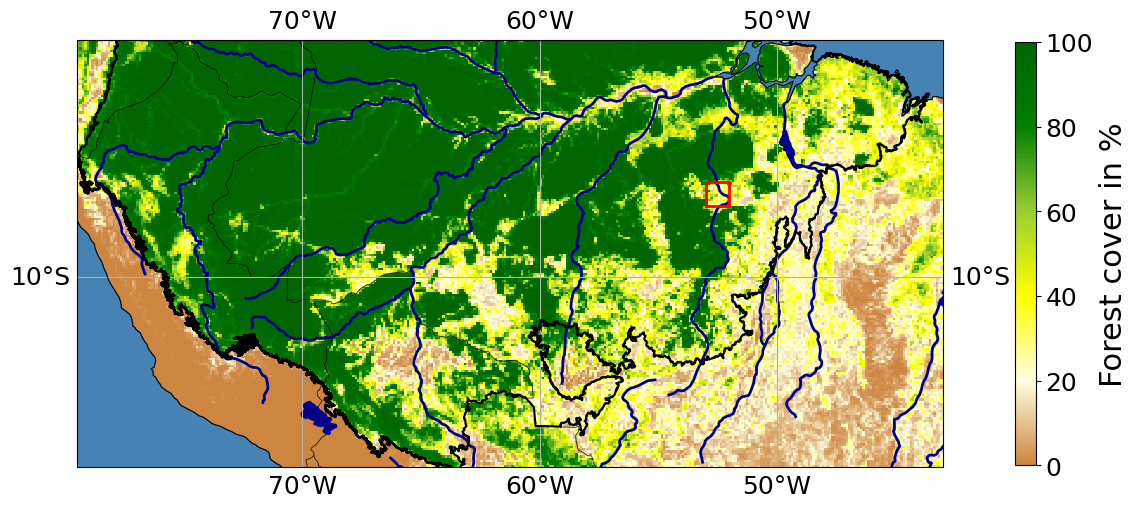

In [24]:
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})

dp=mp2['forest24'].plot.pcolormesh(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap=my_cmap,
    vmin=0, vmax=100,
    cbar_kwargs={'label': 'Forest cover in %', 'pad': 0.065, 'shrink': 0.55}
)
dp.colorbar.set_label('Forest cover in %', fontsize=SG)
dp.colorbar.ax.tick_params(labelsize=SG-4)

ax.add_geometries(
    amazon_south.geometry,
    crs=ccrs.PlateCarree(),
    facecolor="none",
    edgecolor="black",
    linewidth=1.5,
    zorder=5   # make sure it's drawn on top
)

ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.OCEAN, zorder=2, color='steelblue')
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=3)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.RIVERS, linewidth=2, color='darkblue')
ax.add_feature(cfeature.LAKES, linewidth=2, color='darkblue')

gl = ax.gridlines(draw_labels=True)
gl.xlocator = mticker.FixedLocator(range(-90, -39, 10))
gl.ylocator = mticker.FixedLocator(range(-30, 11, 10))
gl.xlabel_style = {'size': SG-4}
gl.ylabel_style = {'size': SG-4}

rect = mpatches.Rectangle(
    (-53, -7),          # lower-left corner: (lon, lat)
    1, 1,                # width, height in degrees
    transform=ccrs.PlateCarree(),
    facecolor='none',
    edgecolor='red',
    linewidth=2,
    zorder=6
)
ax.add_patch(rect)

ax.set_title(None)
plt.tight_layout()
plt.savefig('/home/oscholz/plots/forest/forest_cover_2024.png')
plt.show()

/home/oscholz/miniforge3/envs/modis_env/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/oscholz/miniforge3/envs/modis_env/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


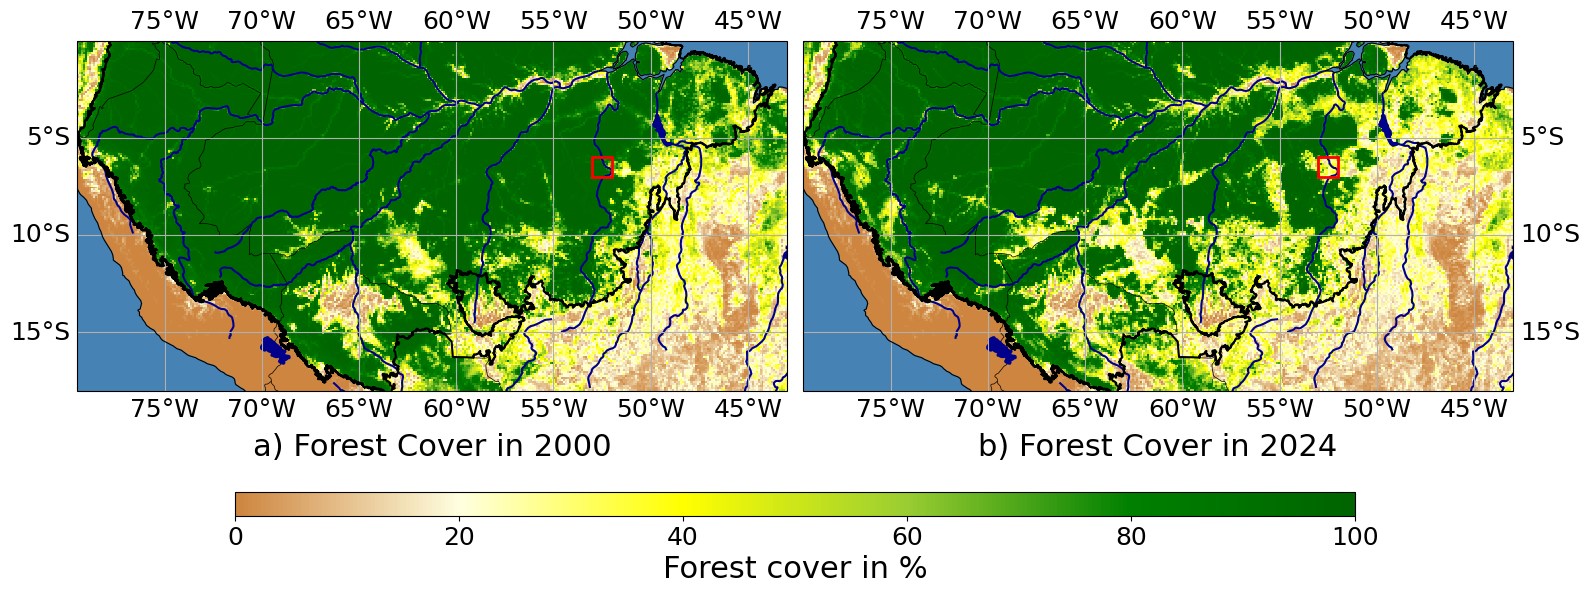

In [35]:
#Generated by Claude Sonet 5 based on the previous plot-codes

fig, axes = plt.subplots(
    1, 2, figsize=(16, 8),
    subplot_kw={'projection': ccrs.PlateCarree()}
)
plt.subplots_adjust(wspace=0.05)  # Plots enger zusammenrücken

datasets = [mp['cover2000'], mp2['forest24']]
captions = ['a) Forest Cover in 2000', 'b) Forest Cover in 2024']

for i, (ax, data) in enumerate(zip(axes, datasets)):
    dp = data.plot.pcolormesh(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=my_cmap,
        vmin=0, vmax=100,
        add_colorbar=False
    )

    ax.add_geometries(
        amazon_south.geometry,
        crs=ccrs.PlateCarree(),
        facecolor="none",
        edgecolor="black",
        linewidth=1.5,
        zorder=5
    )

    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.OCEAN, zorder=2, color='steelblue')
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=3)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.add_feature(cfeature.RIVERS, linewidth=1.5, color='darkblue')
    ax.add_feature(cfeature.LAKES, linewidth=2, color='darkblue')

    gl = ax.gridlines(draw_labels=True)
    gl.xlocator = mticker.FixedLocator(range(-90, -39, 5))
    gl.ylocator = mticker.FixedLocator(range(-30, 11, 5))
    gl.xlabel_style = {'size': SG - 4}
    gl.ylabel_style = {'size': SG - 4}

    # only outer y-labels: left plot -> left only, right plot -> right only
    if i == 0:
        gl.right_labels = False
    else:
        gl.left_labels = False

    rect = mpatches.Rectangle(
        (-53, -7), 1, 1,
        transform=ccrs.PlateCarree(),
        facecolor='none',
        edgecolor='red',
        linewidth=2,
        zorder=6
    )
    ax.add_patch(rect)

    ax.set_title(None)

for ax, caption in zip(axes, captions):
    ax.text(
        0.5, -0.12, caption,
        transform=ax.transAxes,
        ha='center', va='top',
        fontsize=SG
    )

plt.tight_layout(rect=[0, 0.1, 1, 1])

# shared horizontal colorbar under the captions
cbar_ax = fig.add_axes([0.15, 0.175, 0.7, 0.03])  # [left, bottom, width, height]
sm = plt.cm.ScalarMappable(cmap=my_cmap, norm=plt.Normalize(vmin=0, vmax=100))
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Forest cover in %', fontsize=SG)
cbar.ax.tick_params(labelsize=SG - 4)

plt.savefig('/home/oscholz/plots/forest/forest_cover_2000_2024.png', dpi=300, bbox_inches='tight')
plt.show()